# EDA & Data Cleaning
Resume ranking dataset — issues identified and fixed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
df = pd.read_csv(r'C:\Users\sharm\Desktop\Folders\Dataset\resume_data_for_ranking.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (9544, 35)


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


## EDA — Missing Values

                                     missing_count  missing_pct
proficiency_levels                            8844        92.67
languages                                     8844        92.67
address                                       8760        91.79
certification_skills                          7536        78.96
expiry_dates                                  7536        78.96
issue_dates                                   7536        78.96
online_links                                  7536        78.96
certification_providers                       7536        78.96
extra_curricular_organization_names           6118        64.10
extra_curricular_activity_types               6118        64.10
role_positions                                6118        64.10
extra_curricular_organization_links           6118        64.10
career_objective                              4804        50.34
age_requirement                               4087        42.82
skills_required                         

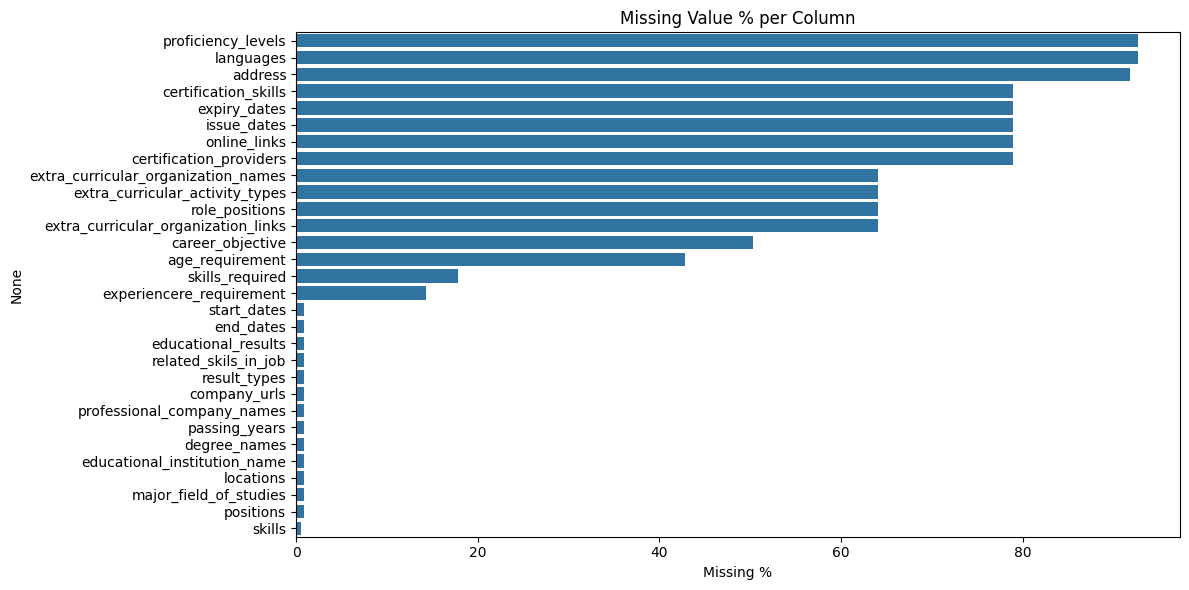

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.missing_pct, y=missing_df.index)
plt.title('Missing Value % per Column')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

## EDA — Target Variable (`matched_score`)

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64


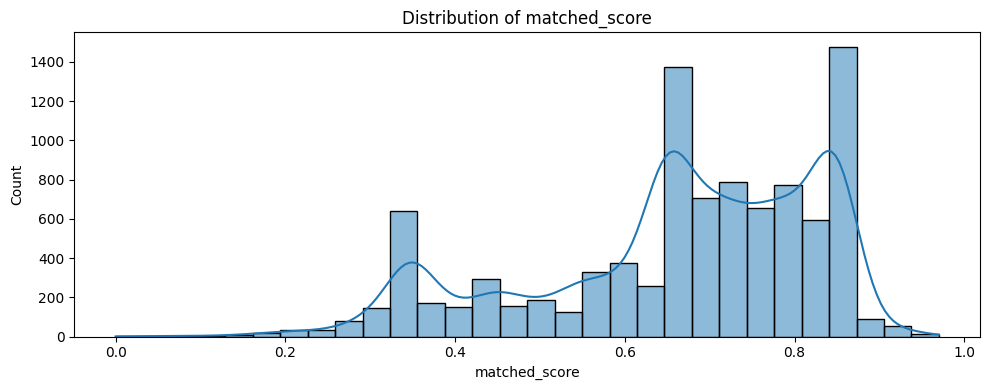

In [4]:
print(df['matched_score'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['matched_score'], bins=30, kde=True)
plt.title('Distribution of matched_score')
plt.xlabel('matched_score')
plt.tight_layout()
plt.show()

## Data Issues Found

| # | Issue | Fix |
|---|---|---|
| 1 | High missing values (>80%) — `address`, `languages`, `certification_*` | Drop columns |
| 2 | List-string columns — `['B.Tech']` stored as string | Parse with pandas str methods |
| 3 | Free-text numeric fields — `'At least 5 years'`, `'Age 25 to 40'` | Extract number with `.str.extract()` |
| 4 | Moderate missing text/numeric columns | Fill with empty string / median |
| 5 | Typos in column names — `educationaL_requirements`, `experiencere_requirement` | Rename |
| 6 | Duplicate column — `responsibilities` and `responsibilities.1` | Check equality → drop |
| 7 | Target variable skew — 87% of scores between 0.5–0.9 | Visualise bucket distribution |

### Issue 1 — High Missing Values (>80%)
Columns with >80% missing carry almost no signal and will hurt model training.  
**Fix:** Drop them.

In [5]:
high_missing_cols = missing_df[missing_df.missing_pct > 80].index.tolist()
print('Dropping:', high_missing_cols)
df.drop(columns=high_missing_cols, inplace=True)
print(f'Shape after drop: {df.shape}')

Dropping: ['proficiency_levels', 'languages', 'address']


Shape after drop: (9544, 32)


### Issue 2 — List-String Encoded Columns
Columns like `degree_names`, `skills` store values as `"['B.Tech', 'M.Tech']"` — a Python list literal inside a string.  
**Fix:** Strip brackets and quotes using pandas string methods.

In [6]:
list_string_cols = ['degree_names', 'major_field_of_studies', 'skills',
                    'skills_required', 'related_skils_in_job', 'positions']

for col in list_string_cols:
    if col in df.columns:
        df[col] = (df[col]
                   .str.strip()
                   .str.strip('[]')
                   .str.replace("'", '', regex=False)
                   .str.strip())

print('Sample after parsing:')
df[['degree_names', 'major_field_of_studies', 'skills']].head(3)

Sample after parsing:


,degree_names,major_field_of_studies,skills
0,B.Tech,Electronics,"Big Data, Hadoop, Hive, Python, Mapreduce, Spa..."
1,"B.Sc (Maths), M.Sc (Science) (Statistics)","Mathematics, Statistics","Data Analysis, Data Analytics, Business Analys..."
2,B.Tech,Electronics/Telecommunication,"Software Development, Machine Learning, Deep L..."


### Issue 3 — Free-Text Numeric Fields
`experiencere_requirement` → `'At least 5 years'`  
`age_requirement` → `'Age 25 to 40 years'`  
These can't be used by any model as-is.  
**Fix:** Extract the first number using pandas `.str.extract()`.

In [7]:
if 'experiencere_requirement' in df.columns:
    df['exp_years_min'] = df['experiencere_requirement'].str.extract(r'(\d+)').astype(float)
    print('exp_years_min distribution:')
    print(df['exp_years_min'].value_counts().sort_index())

if 'age_requirement' in df.columns:
    df['age_min'] = df['age_requirement'].str.extract(r'(\d+)').astype(float)
    print('\nage_min distribution:')
    print(df['age_min'].value_counts().sort_index())

exp_years_min distribution:
exp_years_min
1.0     2047
2.0     1022
3.0     1702
4.0      681
5.0     2387
15.0     341
Name: count, dtype: int64

age_min distribution:
age_min
18.0     342
20.0     340
22.0     682
24.0     341
25.0    2046
28.0     341
30.0     684
40.0     340
52.0     341
Name: count, dtype: int64


### Issue 4 — Moderate Missing Values
- `career_objective`: 50.3% missing
- `skills_required`: 17.8% missing
- `exp_years_min` / `age_min`: missing where original field was NaN

**Fix:** Fill text with empty string; fill numeric with median.

In [8]:
df['career_objective'] = df['career_objective'].fillna('')
df['skills_required'] = df['skills_required'].fillna('')

if 'exp_years_min' in df.columns:
    df['exp_years_min'] = df['exp_years_min'].fillna(df['exp_years_min'].median())
if 'age_min' in df.columns:
    df['age_min'] = df['age_min'].fillna(df['age_min'].median())

cols_to_drop = [c for c in ['experiencere_requirement', 'age_requirement'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f'Shape: {df.shape}')
remaining = df.isnull().sum()
print('Remaining nulls:')
print(remaining[remaining > 0])

Shape: (9544, 32)
Remaining nulls:
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
certification_providers                7536
certification_skills                   7536
online_links                           7536
issue_dates                            75

### Issue 5 — Typos in Column Names
- `educationaL_requirements` — capital L mid-word
- `experiencere_requirement` — extra `re` inserted

**Fix:** Rename to clean snake_case.

In [9]:
rename_map = {
    'educationaL_requirements': 'educational_requirements',
    'experiencere_requirement':  'experience_requirement',
}
rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
df.rename(columns=rename_map, inplace=True)
print('Renamed:', rename_map)
print('Columns:', df.columns.tolist())

Renamed: {'educationaL_requirements': 'educational_requirements'}
Columns: ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educational_requirements', 'responsibilities.1', 'skills_required', 'matched_score', 'exp_years_min', 'age_min']


### Issue 6 — Duplicate `responsibilities` Column
Pandas auto-suffixes duplicate column names as `responsibilities.1` on load.  
**Fix:** Confirm they are identical, then drop the duplicate.

In [10]:
if 'responsibilities.1' in df.columns:
    are_equal = df['responsibilities'].equals(df['responsibilities.1'])
    print(f'responsibilities == responsibilities.1: {are_equal}')
    df.drop(columns=['responsibilities.1'], inplace=True)
    print('Dropped responsibilities.1')
else:
    print('No duplicate responsibilities column found')

responsibilities == responsibilities.1: True
Dropped responsibilities.1


### Issue 7 — Target Variable Skew
87% of scores fall between 0.5–0.9. A model could score well just by predicting the mean (~0.66).  
**Fix:** Visualise distribution per bucket — flag for model evaluation.

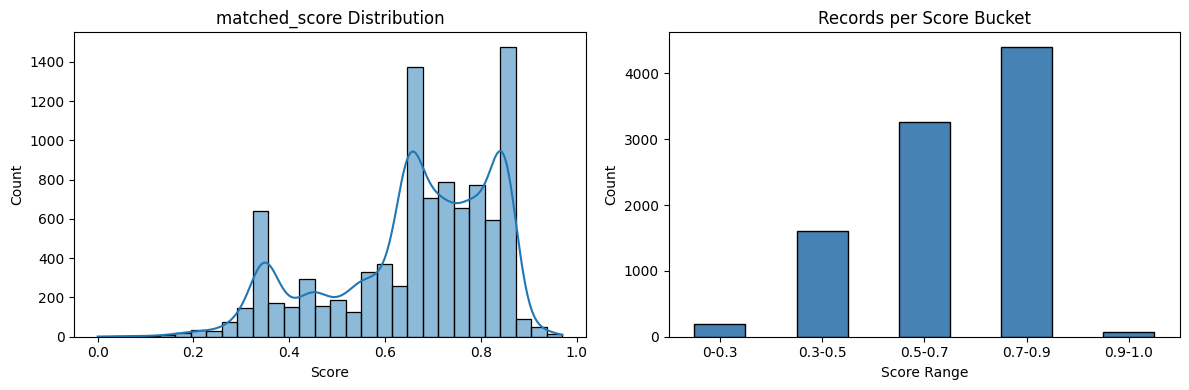

matched_score
0-0.3       195
0.3-0.5    1612
0.5-0.7    3268
0.7-0.9    4402
0.9-1.0      66
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['matched_score'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('matched_score Distribution')
axes[0].set_xlabel('Score')

score_buckets = pd.cut(df['matched_score'],
                       bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
                       labels=['0-0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '0.9-1.0'])
score_buckets.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Records per Score Bucket')
axes[1].set_xlabel('Score Range')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(score_buckets.value_counts().sort_index())

## Engineered Feature — Skill Overlap Ratio

count    7843.000000
mean        0.000128
std         0.011292
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: skill_overlap_ratio, dtype: float64


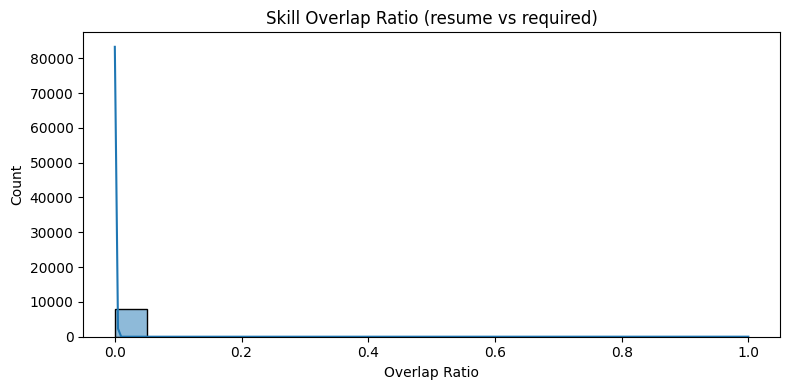

In [12]:
def skill_overlap(row):
    resume_skills = set(str(row.get('skills', '')).lower().split(', '))
    required_skills = set(str(row.get('skills_required', '')).lower().split(', '))
    if not required_skills or required_skills == {''}:
        return np.nan
    return len(resume_skills & required_skills) / len(required_skills)

df['skill_overlap_ratio'] = df.apply(skill_overlap, axis=1)
print(df['skill_overlap_ratio'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['skill_overlap_ratio'].dropna(), bins=20, kde=True)
plt.title('Skill Overlap Ratio (resume vs required)')
plt.xlabel('Overlap Ratio')
plt.tight_layout()
plt.show()

## Correlation Matrix

                     exp_years_min   age_min  skill_overlap_ratio  \
exp_years_min             1.000000  0.742316            -0.002246   
age_min                   0.742316  1.000000            -0.015313   
skill_overlap_ratio      -0.002246 -0.015313             1.000000   
matched_score            -0.045677 -0.071359             0.015632   

                     matched_score  
exp_years_min            -0.045677  
age_min                  -0.071359  
skill_overlap_ratio       0.015632  
matched_score             1.000000  


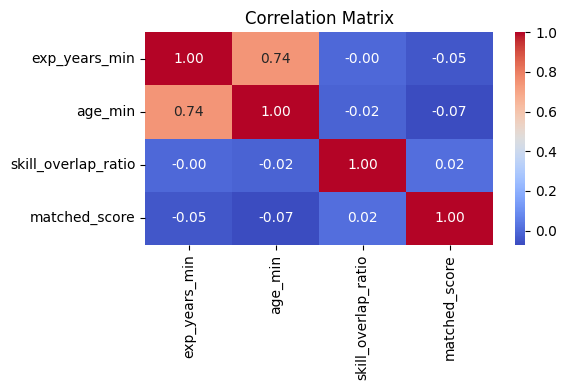

In [13]:
numeric_cols = [c for c in ['exp_years_min', 'age_min', 'skill_overlap_ratio', 'matched_score']
                if c in df.columns]
corr = df[numeric_cols].corr()
print(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Word Cloud — Most Common Words in Text Columns

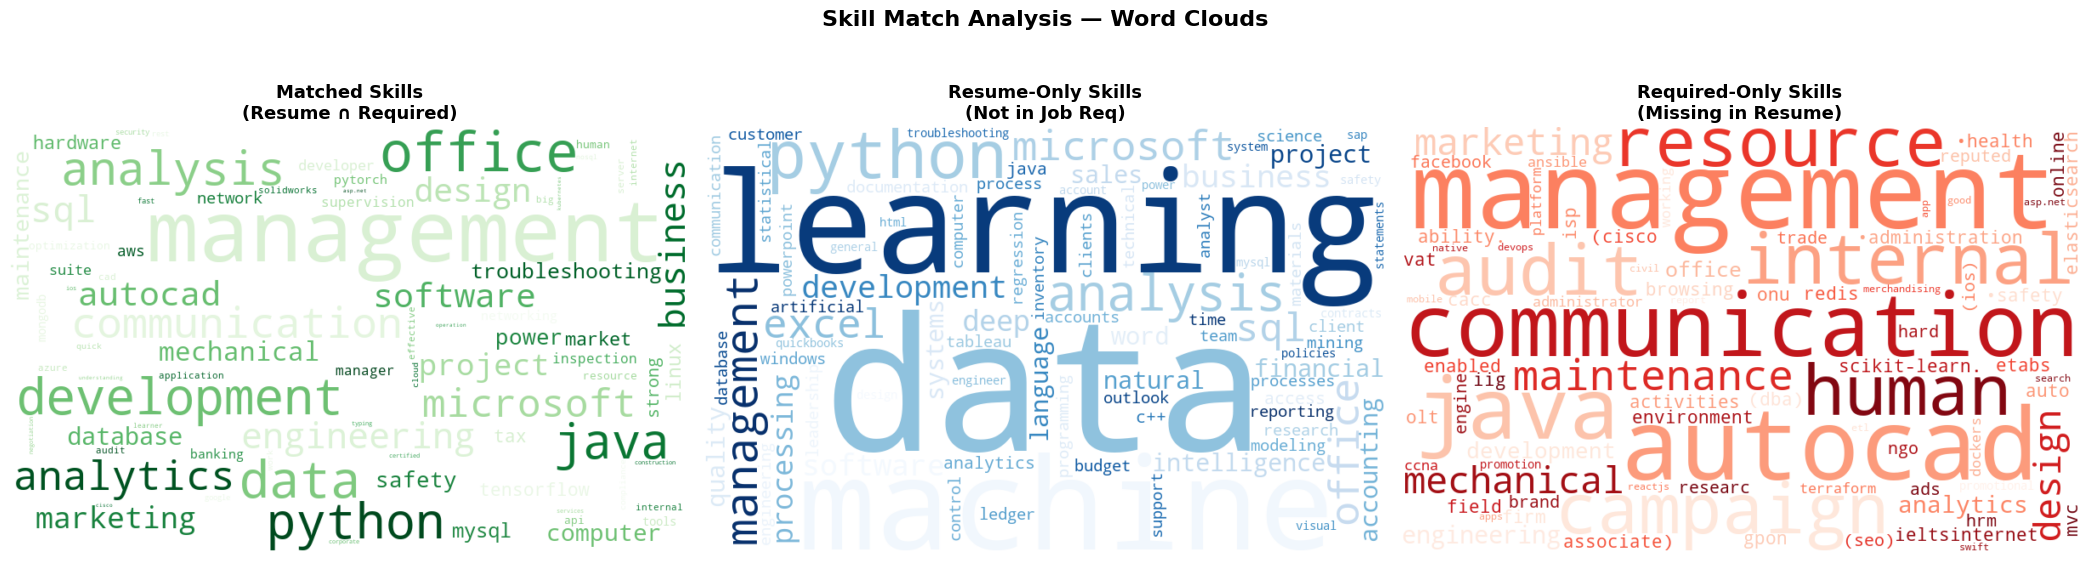

Total matched skill tokens   : 3092
Total resume-only tokens     : 289396
Total required-only tokens   : 57247

Top 10 matched skills   : [('management', 578), ('office', 170), ('data', 143), ('development', 140), ('python', 135), ('java', 132), ('analysis', 121), ('communication', 97), ('analytics', 90), ('microsoft', 83)]
Top 10 skill gaps       : [('management', 1128), ('autocad', 965), ('&', 954), ('communication', 926), ('java', 889), ('campaign', 682), ('audit', 674), ('internal', 674), ('human', 673), ('resource', 673)]


In [14]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

stopwords = set(STOPWORDS)
stopwords.update(['nan', 'none', 'null', 'etc', 'will', 'must', 'also', 'skill', 'skills'])

def tokenize(text):
    return set(str(text).lower().replace(',', ' ').split())

matched_words = []
unmatched_resume = []
unmatched_required = []

for _, row in df.iterrows():
    resume   = tokenize(row.get('skills', ''))
    required = tokenize(row.get('skills_required', ''))
    resume   -= stopwords
    required -= stopwords

    matched_words.extend(resume & required)
    unmatched_resume.extend(resume - required)
    unmatched_required.extend(required - resume)

def make_cloud(word_list, title, ax, colormap):
    freq = Counter(word_list)
    freq = {w: c for w, c in freq.items() if w.strip() and len(w) > 2}
    if not freq:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')
        return
    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        colormap=colormap,
        collocations=False,
        max_words=80,
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

make_cloud(matched_words,    'Matched Skills\n(Resume ∩ Required)',      axes[0], 'Greens')
make_cloud(unmatched_resume, 'Resume-Only Skills\n(Not in Job Req)',     axes[1], 'Blues')
make_cloud(unmatched_required,'Required-Only Skills\n(Missing in Resume)', axes[2], 'Reds')

plt.suptitle('Skill Match Analysis — Word Clouds', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total matched skill tokens   : {len(matched_words)}')
print(f'Total resume-only tokens     : {len(unmatched_resume)}')
print(f'Total required-only tokens   : {len(unmatched_required)}')
print(f'\nTop 10 matched skills   : {Counter(matched_words).most_common(10)}')
print(f'Top 10 skill gaps       : {Counter(unmatched_required).most_common(10)}')


## Save Cleaned Data

In [15]:
output_path = r'C:\Users\sharm\Desktop\Folders\Dataset\resume_data_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Saved to: {output_path}')
print(f'Final shape: {df.shape}')

Saved to: C:\Users\sharm\Desktop\Folders\Dataset\resume_data_cleaned.csv
Final shape: (9544, 32)
